# Day 1: Data Curation — Vietnamese Price Prediction Dataset (v4)

Pipeline: Load JSONL files -> Clean (9-step Vietnamese) -> Category mapping (8 categories) -> Dedup -> EDA -> Weighted sampling -> Split -> Push HF Hub

**Data sources:** Tiki Scraper (102K) + Kaggle (42K) + Hasaki (11K) + WinMart (3.2K) = ~158K raw

**Config:** TRAIN_SIZE=110K, VAL=5K, TEST=5K, total=120K

**Penalties:** Thoi Trang 0.40, Nha Cua 0.60

**HuggingFace:** `SeanSunny/items_raw_tv_v4`

In [7]:
import json
import random
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

from pricer_vi.items import Item
from pricer_vi.parser import parse

In [9]:
# --- Configuration ---

SCRIPT_DIR = Path(".").resolve()
DATA_DIR = SCRIPT_DIR.parent / "Tiki" / "Tiki_dataset_scrape"
OUTPUT_DIR = SCRIPT_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
HF_DATASET_NAME = "SeanSunny/items_raw_tv_v4"
TRAIN_SIZE = 110_000
VAL_SIZE = 5_000
TEST_SIZE = 5_000

print(f"Data dir: {DATA_DIR}")
print(f"Total target: {TRAIN_SIZE + VAL_SIZE + TEST_SIZE:,} items")

Data dir: /home/hieu0606sunny/price2026wsl/tech2ai/scraping_data_tv/Tiki/Tiki_dataset_scrape
Total target: 120,000 items


In [10]:
# --- 8 Target Categories + Mapping ---

CATEGORY_MAP = {
    # Thoi Trang (gop fashion + phu kien + balo)
    "Th\u1eddi Trang": "Th\u1eddi Trang",
    "Th\u1eddi trang n\u1eef": "Th\u1eddi Trang",
    "Th\u1eddi trang nam": "Th\u1eddi Trang",
    "Ph\u1ee5 ki\u1ec7n th\u1eddi trang": "Th\u1eddi Trang",
    "Balo v\u00e0 Vali": "Th\u1eddi Trang",
    # Nha Cua (gop cham soc nha cua)
    "Nh\u00e0 C\u1eeda - \u0110\u1eddi S\u1ed1ng": "Nh\u00e0 C\u1eeda - \u0110\u1eddi S\u1ed1ng",
    "Ch\u0103m s\u00f3c nh\u00e0 c\u1eeda": "Nh\u00e0 C\u1eeda - \u0110\u1eddi S\u1ed1ng",
    # Dien Tu - Cong Nghe
    "Laptop - M\u00e1y Vi T\u00ednh - Linh ki\u1ec7n": "\u0110i\u1ec7n T\u1eed - C\u00f4ng Ngh\u1ec7",
    "Thi\u1ebft B\u1ecb S\u1ed1 - Ph\u1ee5 Ki\u1ec7n S\u1ed1": "\u0110i\u1ec7n T\u1eed - C\u00f4ng Ngh\u1ec7",
    # Lam Dep
    "L\u00e0m \u0110\u1eb9p - S\u1ee9c Kh\u1ecfe": "L\u00e0m \u0110\u1eb9p - S\u1ee9c Kh\u1ecfe",
    # Me va Be (gop Do Choi)
    "\u0110\u1ed3 Ch\u01a1i - M\u1eb9 & B\u00e9": "M\u1eb9 v\u00e0 B\u00e9",
    # Dien Lanh va Gia Dung
    "\u0110i\u1ec7n Gia D\u1ee5ng": "\u0110i\u1ec7n L\u1ea1nh v\u00e0 Gia D\u1ee5ng",
    "\u0110i\u1ec7n T\u1eed - \u0110i\u1ec7n L\u1ea1nh": "\u0110i\u1ec7n L\u1ea1nh v\u00e0 Gia D\u1ee5ng",
    # Bach Hoa
    "B\u00e1ch H\u00f3a Online": "B\u00e1ch H\u00f3a",
    "Th\u1ef1c ph\u1ea9m": "B\u00e1ch H\u00f3a",
    "Phi th\u1ef1c ph\u1ea9m": "B\u00e1ch H\u00f3a",
    # O To
    "\u00d4 T\u00f4 - Xe M\u00e1y - Xe \u0110\u1ea1p": "\u00d4 T\u00f4 - Xe M\u00e1y",
    # Bo
    "Nh\u00e0 S\u00e1ch Tiki": None,
}

SUBCATEGORY_OVERRIDES = {
    "Th\u1ec3 thao": "Nh\u00e0 C\u1eeda - \u0110\u1eddi S\u1ed1ng",
    "Qu\u00e0 l\u01b0u ni\u1ec7m": "M\u1eb9 v\u00e0 B\u00e9",
    "V\u0103n ph\u00f2ng ph\u1ea9m": "Nh\u00e0 C\u1eeda - \u0110\u1eddi S\u1ed1ng",
}

CATEGORY_PENALTIES = {
    "Th\u1eddi Trang": 0.40,
    "Nh\u00e0 C\u1eeda - \u0110\u1eddi S\u1ed1ng": 0.60,
}

print(f"Categories: {len(set(v for v in CATEGORY_MAP.values() if v)):}")
print(f"Penalties: {CATEGORY_PENALTIES}")

Categories: 8
Penalties: {'Thời Trang': 0.4, 'Nhà Cửa - Đời Sống': 0.6}


## Step 1: Explore a single JSONL file

Before loading everything, let's look at what one file contains.

In [11]:
# Pick one file to explore
sample_files = sorted(DATA_DIR.glob("*.jsonl"))[:5]
for f in sample_files:
    count = sum(1 for _ in open(f, encoding="utf-8"))
    print(f"{f.name}: {count:,} items")

hasaki_category_102.jsonl: 78 items
hasaki_category_107.jsonl: 87 items
hasaki_category_108.jsonl: 14 items
hasaki_category_109.jsonl: 67 items
hasaki_category_11.jsonl: 369 items


In [17]:
# Look at one raw datapoint
first_file = sorted(DATA_DIR.glob("*.jsonl"))[5]
with open(first_file, encoding="utf-8") as f:
    datapoint = json.loads(f.readline())

print(f"File: {first_file.name}")
print(f"Keys: {list(datapoint.keys())}")
print(f"Title: {datapoint.get('title', '')[:100]}")
print(f"Price: {datapoint.get('price', 0):,} VND")
print(f"Category: {datapoint.get('category', '')}")
print(f"Brand: {datapoint.get('brand', '')}")
print(f"Features (first 300 chars): {datapoint.get('features', '')[:300]}")

File: hasaki_category_110.jsonl
Keys: ['title', 'price', 'features', 'brand', 'category']
Title: Kem Ủ Tóc Dove Ceramide Phục Hồi Hư Tổn 300ml (Mới)
Price: 129,000 VND
Category: Làm Đẹp - Sức Khỏe > Chăm Sóc Tóc Và Da Đầu > Dưỡng Tóc > Mặt Nạ / Kem Ủ Tóc
Brand: Dove
Features (first 300 chars): Kem Ủ Tóc Dove Treatment Mask 300ml là sản phẩm ủ tóc đến từ thương hiệu Dove - Mỹ. Sản phẩm được thiết kế để phục hồi . . . | Barcode: 8934868192541 | Thương Hiệu: Dove | Xuất xứ thương hiệu: Mỹ | Nơi sản xuất: Thailand | Giới tính: Nam và nữ | Dung Tích: 300ml | Kem Ủ Tóc Dove Treatment Mask 300ml


In [18]:
# Parse it into an Item
raw_cat = datapoint.get("category", "")
parent = raw_cat.split(" > ")[0]
mapped = CATEGORY_MAP.get(parent, "UNKNOWN")
print(f"Raw category: {raw_cat}")
print(f"Parent: {parent}")
print(f"Mapped to: {mapped}")

if mapped and mapped != "UNKNOWN":
    item = parse(datapoint, mapped)
    if item:
        print(f"\nParsed: {item}")
        print(f"Full text ({len(item.full)} chars):\n{item.full[:500]}")

Raw category: Làm Đẹp - Sức Khỏe > Chăm Sóc Tóc Và Da Đầu > Dưỡng Tóc > Mặt Nạ / Kem Ủ Tóc
Parent: Làm Đẹp - Sức Khỏe
Mapped to: Làm Đẹp - Sức Khỏe

Parsed: title='Kem Ủ Tóc Dove Ceramide Phục Hồi Hư Tổn 300ml (Mới)' category='Làm Đẹp - Sức Khỏe' price=129000 full='Kem Ủ Tóc Dove Ceramide Phục Hồi Hư Tổn 300ml (Mới)\nKem Ủ Tóc Dove Treatment Mask 300ml là sản phẩm ủ tóc đến từ thương hiệu Dove - Mỹ. Sản phẩm được thiết kế để phục hồi . . . Thương Hiệu: Dove | Xuất xứ thương hiệu: Mỹ | Nơi sản xuất: Thailand | Giới tính: Nam và nữ | Dung Tích: 300ml | Kem Ủ Tóc Dove Treatment Mask 300ml là sản phẩm ủ tóc đến từ thương hiệu Dove - Mỹ. Sản phẩm được thiết kế để phục hồi và nuôi dưỡng tóc hư tổn, đặc biệt phù hợp cho những mái tóc yếu, dễ gãy rụng, mang lại sự mềm mượt và khỏe mạnh cho tóc chỉ sau vài lần sử dụng. Ủ Tóc Dove Treatment Mask 300ml hiện đã có tại Hasaki với 2 phân loại cùng 2 phiên bản CŨ - MỚI : Kem Ủ Tóc Dove Biotin Hya + Biotin Anti Hair Fall Treatment Mask Giảm Gãy Rụng 3

In [19]:
# Explore a WinMart file (FMCG)
winmart_files = sorted(DATA_DIR.glob("winmart_*.jsonl"))
print(f"WinMart files: {len(winmart_files)}")
for f in winmart_files[:3]:
    count = sum(1 for _ in open(f, encoding="utf-8"))
    print(f"  {f.name}: {count:,} items")

if winmart_files:
    with open(winmart_files[0], encoding="utf-8") as f:
        wm = json.loads(f.readline())
    print(f"\nWinMart sample:")
    print(f"  Title: {wm.get('title', '')}")
    print(f"  Price: {wm.get('price', 0):,} VND")
    print(f"  Category: {wm.get('category', '')}")
    print(f"  Features: {wm.get('features', '')[:200]}")

WinMart files: 18
  winmart_banh-keo.jsonl: 466 items
  winmart_cham-soc-be.jsonl: 48 items
  winmart_cham-soc-ca-nhan.jsonl: 514 items

WinMart sample:
  Title: Kẹo Socola Ferrero Rocher 375g
  Price: 448,000 VND
  Category: Thực phẩm > Thực phẩm công nghệ > Bánh kẹo > Kẹo & Chocolate > Chocolate
  Features: FERRERO Kẹo Socola Rocher 375g


## Step 2: Load all JSONL files

Load 263 JSONL files from Tiki + Kaggle + Hasaki + WinMart, apply category mapping.

In [20]:
def _map_category(raw_cat: str, is_kaggle: bool) -> str | None:
    """Map a raw category string to one of 8 target categories, or None to drop."""
    if is_kaggle:
        return "Th\u1eddi Trang"
    parts = raw_cat.split(" > ")
    parent = parts[0]
    sub = parts[1] if len(parts) > 1 else ""
    for keyword, target in SUBCATEGORY_OVERRIDES.items():
        if keyword in sub or keyword in parent:
            return target
    if parent in CATEGORY_MAP:
        return CATEGORY_MAP[parent]
    return None


def load_all_items() -> list[Item]:
    """Load all JSONL files, parse into Item objects with 8-category mapping."""
    items = []
    dropped_cats = Counter()
    for filepath in tqdm(sorted(DATA_DIR.glob("*.jsonl")), desc="Loading files"):
        is_kaggle = "kaggle" in filepath.name
        count = 0
        for line in open(filepath, encoding="utf-8"):
            datapoint = json.loads(line)
            raw_cat = datapoint.get("category", "")
            category = _map_category(raw_cat, is_kaggle)
            if category is None:
                dropped_cats[raw_cat.split(" > ")[0] if " > " in raw_cat else raw_cat] += 1
                continue
            item = parse(datapoint, category)
            if item:
                items.append(item)
                count += 1
        if count > 0:
            print(f"  {filepath.name}: {count:,} items")
    if dropped_cats:
        print(f"\nDropped categories:")
        for cat, cnt in dropped_cats.most_common():
            print(f"  {cat}: {cnt:,} items")
    return items

In [21]:
items = load_all_items()
print(f"\nLoaded: {len(items):,} items from {len(list(DATA_DIR.glob('*.jsonl')))} files")

Loading files:   0%|          | 0/263 [00:00<?, ?it/s]

  hasaki_category_102.jsonl: 78 items
  hasaki_category_107.jsonl: 87 items
  hasaki_category_108.jsonl: 14 items
  hasaki_category_109.jsonl: 67 items
  hasaki_category_11.jsonl: 369 items
  hasaki_category_110.jsonl: 38 items
  hasaki_category_114.jsonl: 10 items
  hasaki_category_128.jsonl: 95 items
  hasaki_category_13.jsonl: 62 items
  hasaki_category_133.jsonl: 29 items
  hasaki_category_136.jsonl: 96 items
  hasaki_category_137.jsonl: 28 items
  hasaki_category_140.jsonl: 61 items
  hasaki_category_141.jsonl: 21 items
  hasaki_category_142.jsonl: 84 items
  hasaki_category_147.jsonl: 231 items
  hasaki_category_17.jsonl: 169 items
  hasaki_category_178.jsonl: 58 items
  hasaki_category_1849.jsonl: 12 items
  hasaki_category_1857.jsonl: 157 items
  hasaki_category_1859.jsonl: 75 items
  hasaki_category_1861.jsonl: 40 items
  hasaki_category_1877.jsonl: 433 items
  hasaki_category_1879.jsonl: 403 items
  hasaki_category_1881.jsonl: 275 items
  hasaki_category_1883.jsonl: 543 items

In [22]:
# Quick look at a few items
for item in items[:3]:
    print(f"{item}  |  full={len(item.full)} chars  |  brand={item.brand}")
    print(f"  {item.full[:150]}...")
    print()

title='Serum Dưỡng Tóc TRESemmé Vào Nếp Suôn Mượt 100ml (Mới)' category='Làm Đẹp - Sức Khỏe' price=144000 full='Serum Dưỡng Tóc TRESemmé Vào Nếp Suôn Mượt 100ml (Mới)\nSerum Dưỡng Tóc TRESemmé là sản phẩm serum dưỡng tóc đến từ thương hiệu TRESemmé - Mỹ, giúp phục hồi và nuôi dưỡng mái tóc từ gốc đến . . . Thương Hiệu: TRESemmé | Xuất xứ thương hiệu: Mỹ | Giới tính: Nam và nữ | Dung Tích: 100ml | Serum Dưỡng Tóc TRESemmé là sản phẩm serum dưỡng tóc đến từ thương hiệu TRESemmé - Mỹ, giúp phục hồi và nuôi dưỡng mái tóc từ gốc đến ngọn. Với công nghệ tiên tiến như KeratinBond+, PeptideBond+ và LamellarBond+ , serum mang lại nhiều công dụng vượt trội như giữ nếp suôn mượt, giảm xù rối, phục hồi tóc hư tổn và ngăn ngừa gãy rụng. Kết cấu lỏng nhẹ, dễ thấm, không gây bết dính, thích hợp sử dụng hàng ngày cho mọi loại tóc. Giải pháp lý tưởng để bạn có được mái tóc mềm mượt, khỏe mạnh chuẩn salon ngay tại nhà. Serum Dưỡng Tóc TRESemmé hiện đã có tại Hasaki với 3 phân loại: Serum Dưỡng Tóc TRESe

## Step 3: EDA before dedup

Explore price, text length, and category distributions on the raw loaded data.

In [23]:
def plot_eda(items: list[Item], prefix: str = "", save: bool = True):
    """Generate 5 EDA charts. Optionally save to output/."""
    lengths = [len(item.full) for item in items]
    prices = [item.price for item in items]
    cat_counts = Counter([item.category for item in items])
    categories = list(cat_counts.keys())
    counts = [cat_counts[c] for c in categories]

    # --- Stats ---
    print(f"--- EDA Stats ({prefix.strip('_') or 'raw'}) ---")
    print(f"Total items: {len(items):,}")
    print(f"Price: min={min(prices):,}, max={max(prices):,}, avg={sum(prices)/len(prices):,.0f}, median={int(np.median(prices)):,}")
    print(f"Text length: min={min(lengths)}, max={max(lengths):,}, avg={sum(lengths)/len(lengths):,.0f}")
    print(f"Categories: {len(cat_counts)}")
    for cat, cnt in cat_counts.most_common():
        print(f"  {cat}: {cnt:,} ({cnt/len(items)*100:.1f}%)")

    # 1. Text length histogram
    plt.figure(figsize=(15, 6))
    plt.title(f"Text length: Avg {sum(lengths)/len(lengths):,.0f} and highest {max(lengths):,}\n")
    plt.xlabel("Length (chars)")
    plt.ylabel("Count")
    plt.hist(lengths, rwidth=0.7, color="skyblue", bins=range(0, min(max(lengths) + 100, 6000), 100))
    if save:
        plt.savefig(OUTPUT_DIR / f"{prefix}length_distribution.png", dpi=100, bbox_inches="tight")
    plt.show()

    # 2. Price histogram (log-scale for VND)
    plt.figure(figsize=(15, 6))
    plt.title(f"Prices (VND): Avg {sum(prices)/len(prices):,.0f}, Median {int(np.median(prices)):,}\n")
    plt.xlabel("Price (VND)")
    plt.ylabel("Count")
    log_bins = np.logspace(np.log10(max(min(prices), 1)), np.log10(max(prices) + 1), 50)
    plt.hist(prices, rwidth=0.7, color="blueviolet", bins=log_bins)
    plt.xscale("log")
    if save:
        plt.savefig(OUTPUT_DIR / f"{prefix}price_distribution.png", dpi=100, bbox_inches="tight")
    plt.show()

    # 3. Category bar chart
    plt.figure(figsize=(15, 6))
    plt.bar(categories, counts, color="goldenrod")
    plt.title("How many in each category")
    plt.xlabel("Categories")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    for i, v in enumerate(counts):
        plt.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    if save:
        plt.savefig(OUTPUT_DIR / f"{prefix}category_distribution.png", dpi=100, bbox_inches="tight")
    plt.show()

    # 4. Category pie chart
    plt.figure(figsize=(12, 10))
    plt.pie(counts, labels=categories, autopct="%1.0f%%", startangle=90)
    centre_circle = plt.Circle((0, 0), 0.70, fc="white")
    plt.gcf().gca().add_artist(centre_circle)
    plt.title("Categories")
    plt.axis("equal")
    if save:
        plt.savefig(OUTPUT_DIR / f"{prefix}category_pie.png", dpi=100, bbox_inches="tight")
    plt.show()

    # 5. Price vs text length scatter
    plt.figure(figsize=(15, 8))
    plt.scatter(lengths, prices, s=0.2, color="red")
    plt.xlabel("Text length (chars)")
    plt.ylabel("Price (VND)")
    plt.title("Is there a simple correlation with text length?")
    if save:
        plt.savefig(OUTPUT_DIR / f"{prefix}price_vs_length.png", dpi=100, bbox_inches="tight")
    plt.show()

--- EDA Stats (01_before_dedup) ---
Total items: 157,722
Price: min=1,000, max=50,000,000, avg=1,034,152, median=224,000
Text length: min=50, max=3,256, avg=1,519
Categories: 8
  Thời Trang: 56,170 (35.6%)
  Nhà Cửa - Đời Sống: 33,355 (21.1%)
  Điện Tử - Công Nghệ: 22,977 (14.6%)
  Làm Đẹp - Sức Khỏe: 21,032 (13.3%)
  Bách Hóa: 8,137 (5.2%)
  Mẹ và Bé: 7,312 (4.6%)
  Điện Lạnh và Gia Dụng: 6,097 (3.9%)
  Ô Tô - Xe Máy: 2,642 (1.7%)


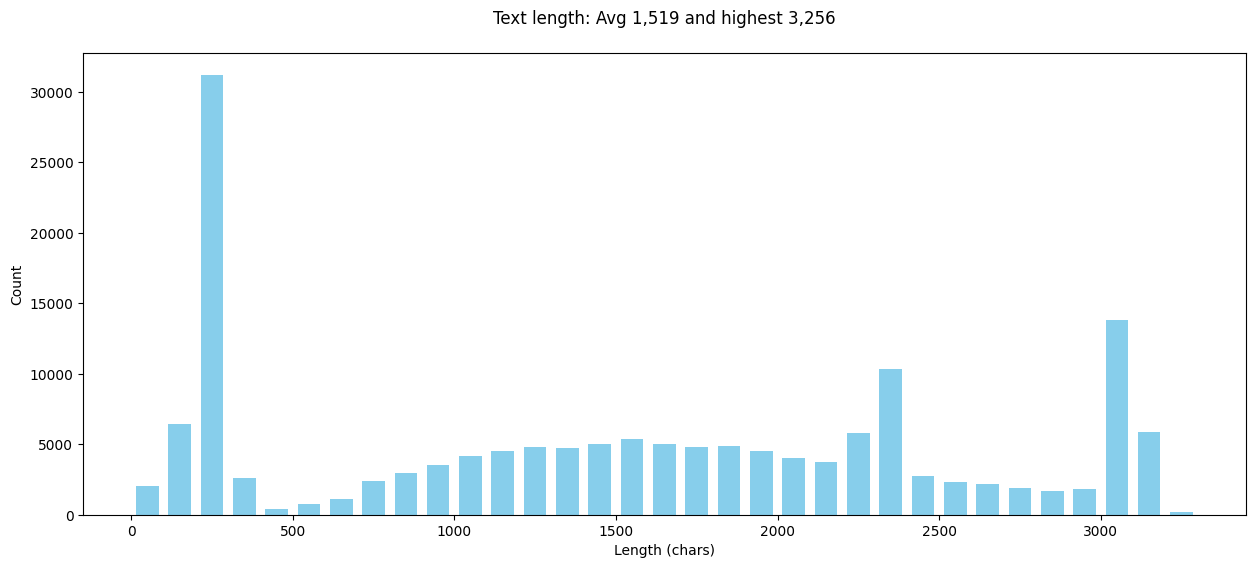

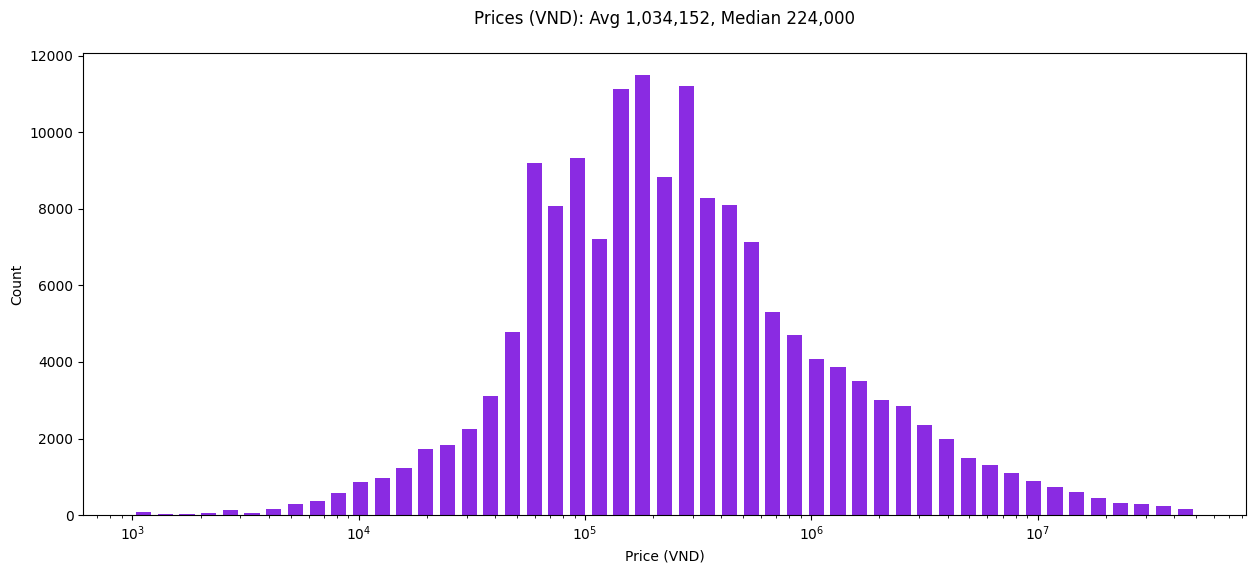

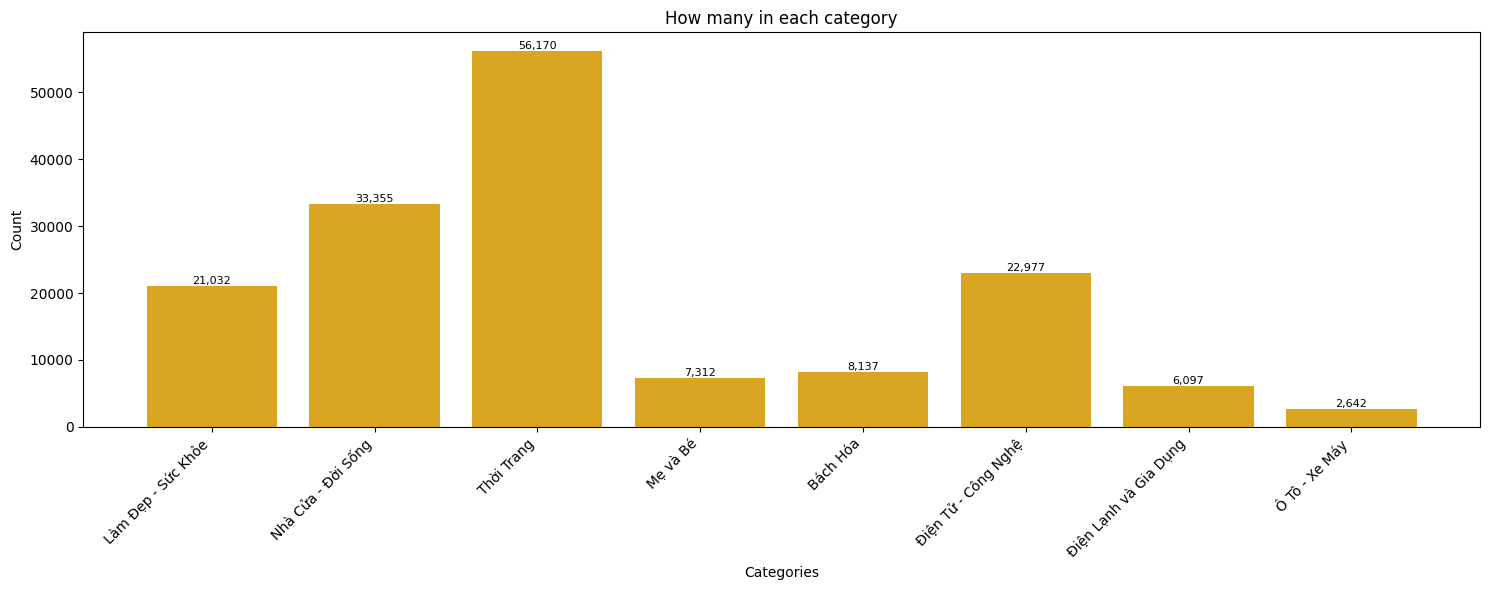

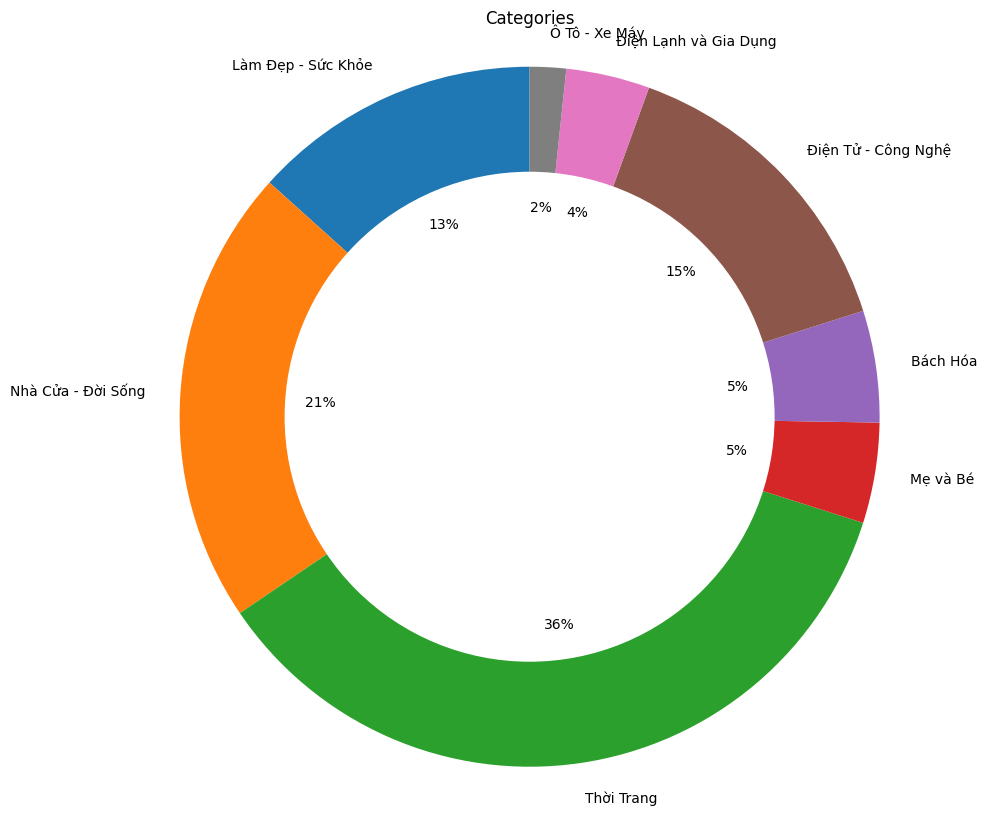

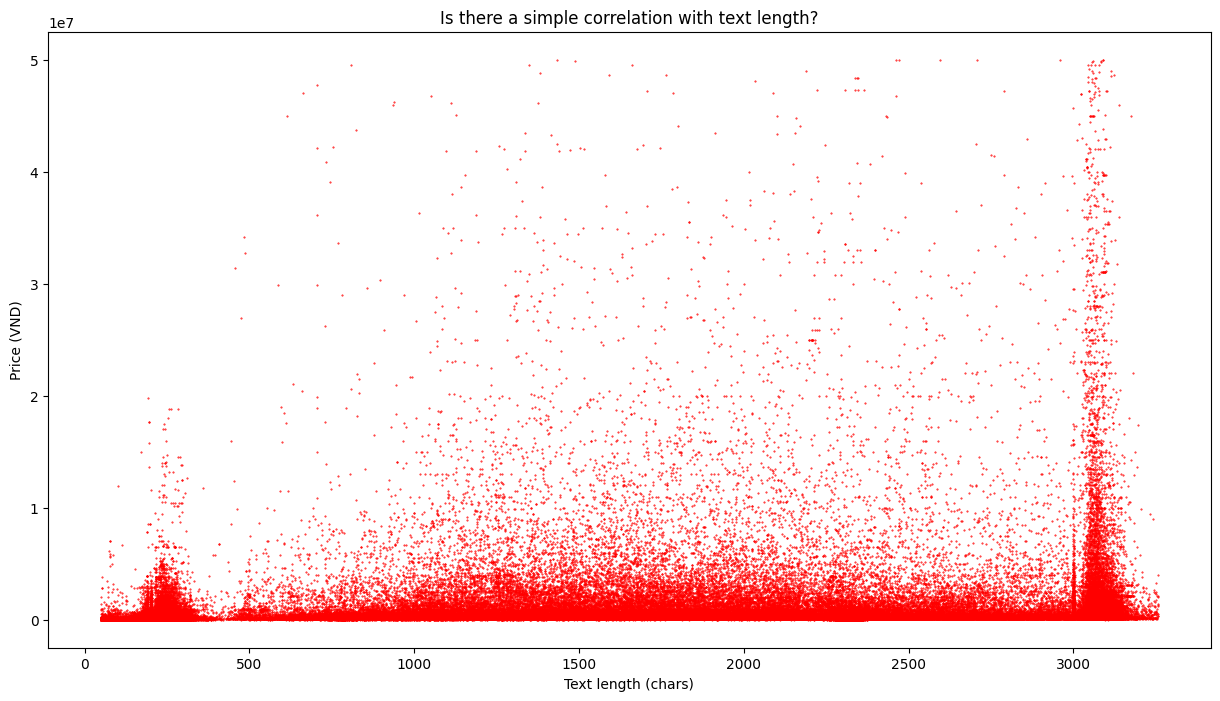

In [24]:
plot_eda(items, prefix="01_before_dedup_")

## Step 4: Deduplication

Shuffle then remove duplicates by title and by full text to prevent data leakage.

In [25]:
random.seed(RANDOM_SEED)
random.shuffle(items)

before = len(items)

seen = set()
items = [x for x in tqdm(items, desc="Dedup by title")
         if not (x.title in seen or seen.add(x.title))]
after_title = len(items)

seen = set()
items = [x for x in tqdm(items, desc="Dedup by full")
         if not (x.full in seen or seen.add(x.full))]
del seen

print(f"Before: {before:,}")
print(f"After title dedup: {after_title:,} (removed {before - after_title:,})")
print(f"After full dedup: {len(items):,} (removed {after_title - len(items):,})")
print(f"Total removed: {before - len(items):,} ({(before - len(items))/before*100:.1f}%)")

Dedup by title:   0%|          | 0/157722 [00:00<?, ?it/s]

Dedup by full:   0%|          | 0/147097 [00:00<?, ?it/s]

Before: 157,722
After title dedup: 147,097 (removed 10,625)
After full dedup: 146,850 (removed 247)
Total removed: 10,872 (6.9%)


## Step 5: EDA after dedup

--- EDA Stats (02_after_dedup) ---
Total items: 146,850
Price: min=1,000, max=50,000,000, avg=1,075,220, median=229,000
Text length: min=50, max=3,256, avg=1,524
Categories: 8
  Thời Trang: 51,465 (35.0%)
  Nhà Cửa - Đời Sống: 31,987 (21.8%)
  Điện Tử - Công Nghệ: 22,734 (15.5%)
  Làm Đẹp - Sức Khỏe: 16,730 (11.4%)
  Bách Hóa: 8,073 (5.5%)
  Mẹ và Bé: 7,247 (4.9%)
  Điện Lạnh và Gia Dụng: 6,005 (4.1%)
  Ô Tô - Xe Máy: 2,609 (1.8%)


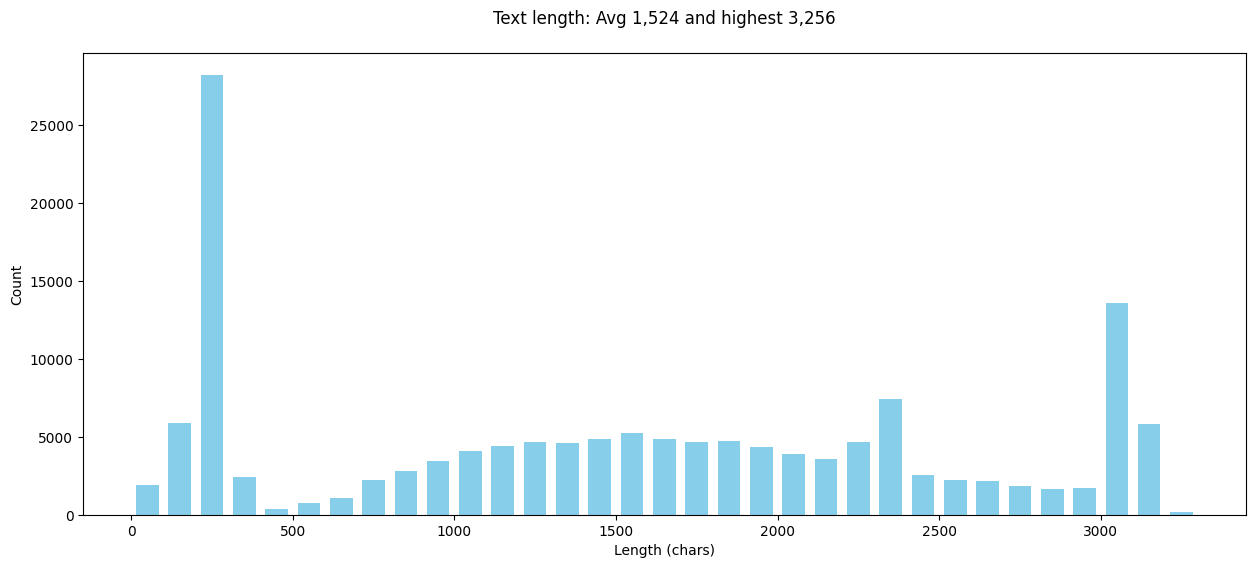

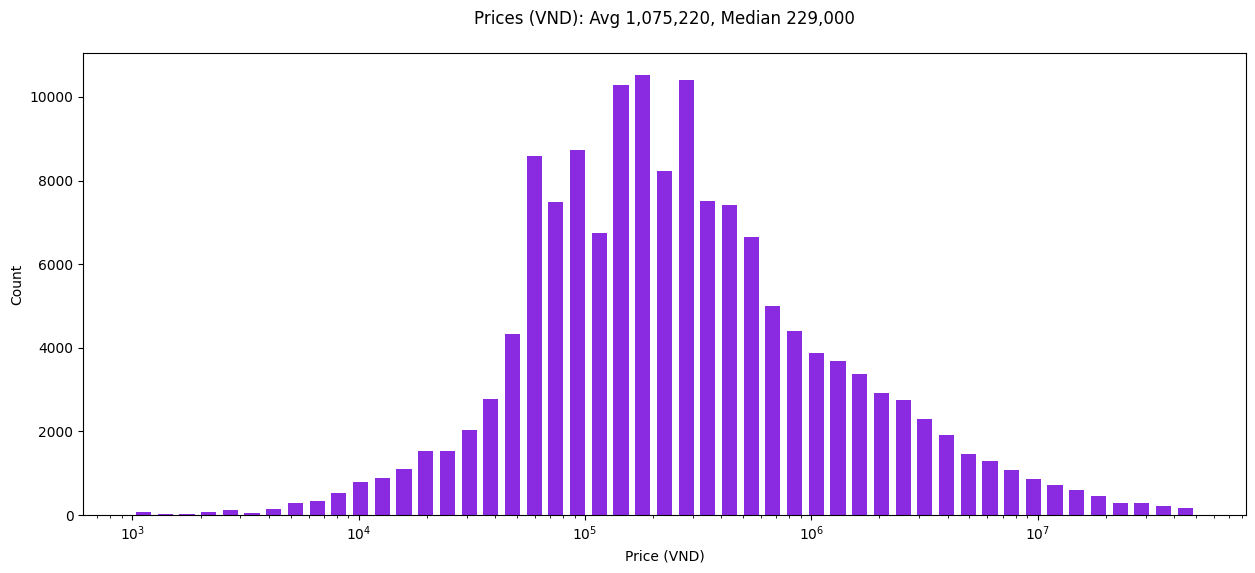

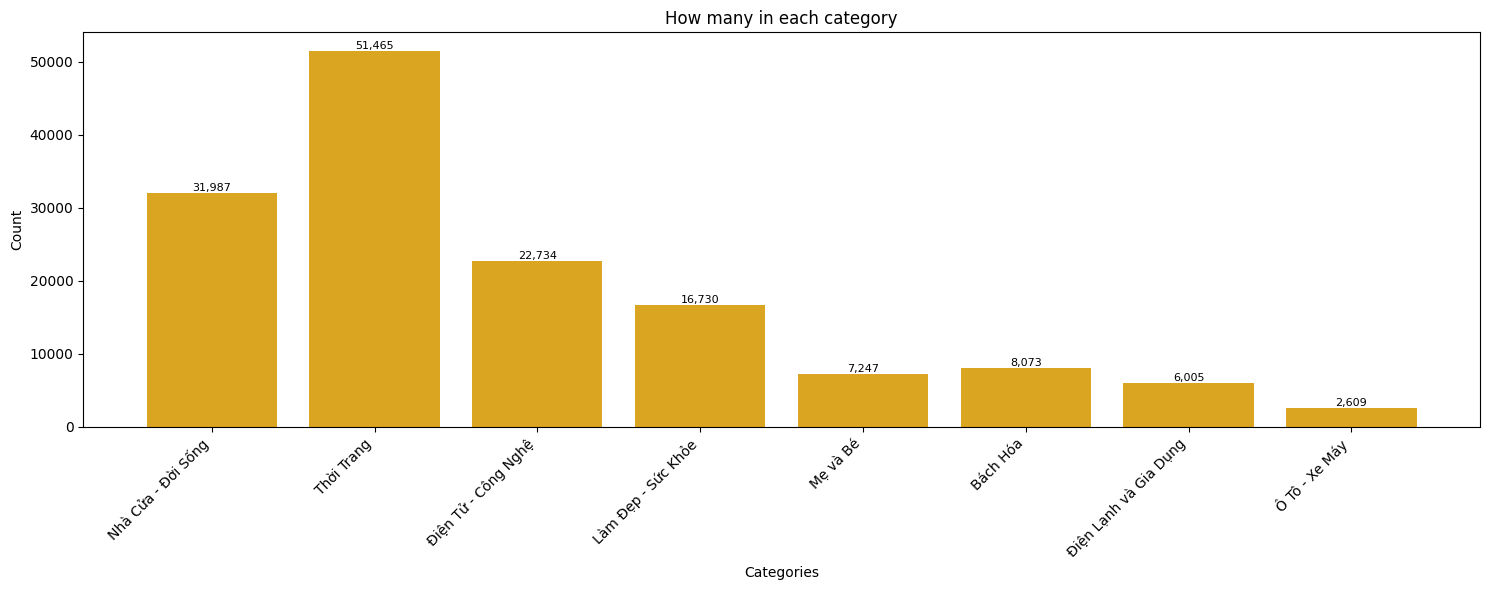

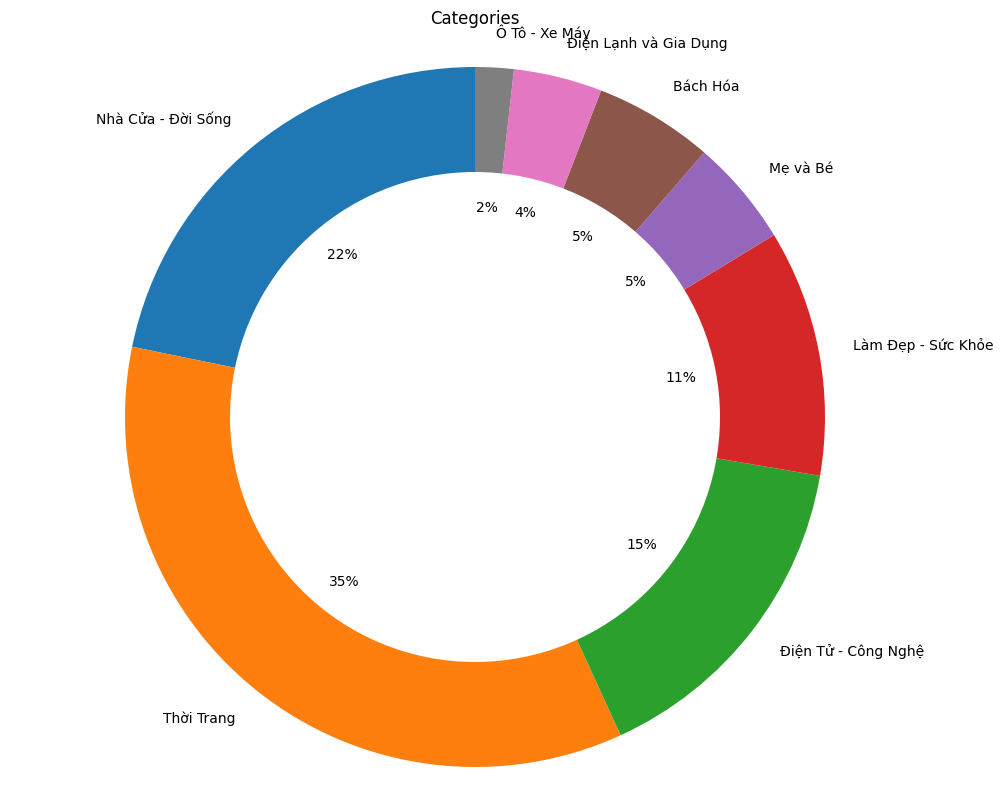

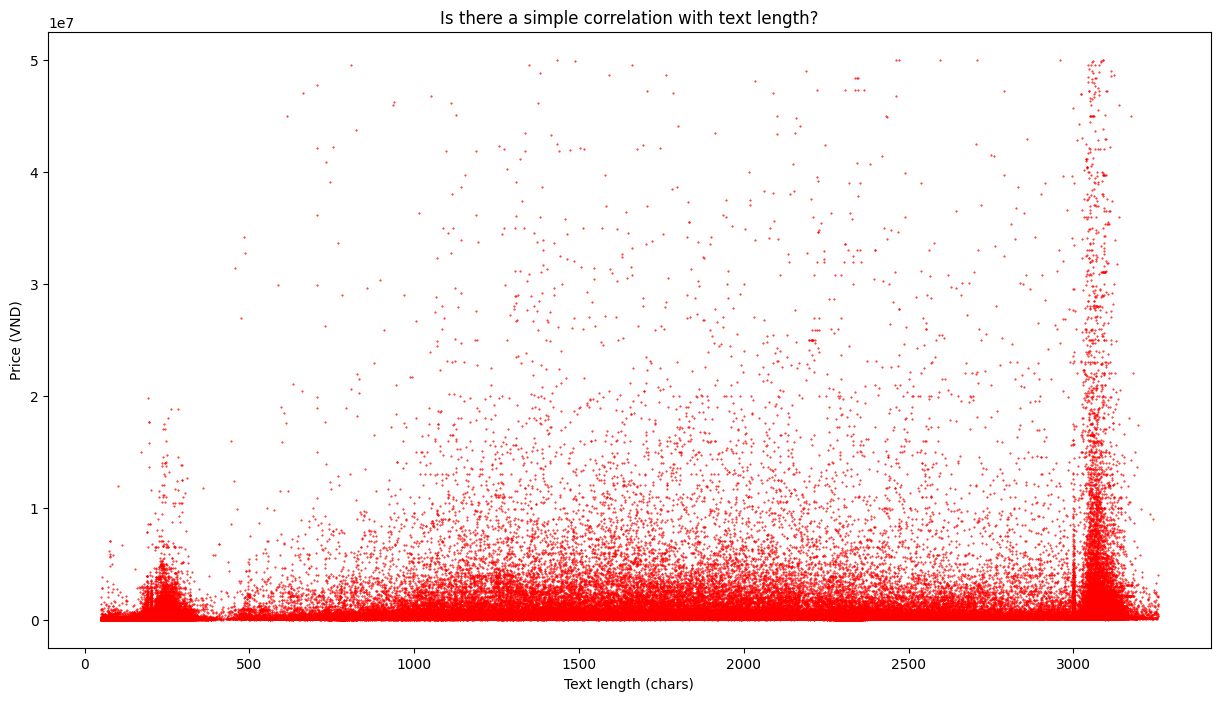

In [26]:
plot_eda(items, prefix="02_after_dedup_")

## Step 6: Weighted Sampling

Apply price^2 weighting (boost expensive items) and category penalties to create a balanced sample.

Same technique as English pipeline (day1.ipynb):
- `price^2` weighting shifts avg price up, reducing bias toward cheap items
- Category penalties reduce over-represented categories

In [27]:
target_size = TRAIN_SIZE + VAL_SIZE + TEST_SIZE
total = len(items)

print(f"Available: {total:,} items")
print(f"Target: {target_size:,} items")
print(f"Sampling rate: {target_size/total*100:.1f}%")

if total <= target_size:
    print(f"Not enough data! Using all {total:,} items.")
    sample_size = total
else:
    sample_size = target_size
    print(f"Will drop {total - target_size:,} items ({(total - target_size)/total*100:.1f}%)")

Available: 146,850 items
Target: 120,000 items
Sampling rate: 81.7%
Will drop 26,850 items (18.3%)


In [28]:
np.random.seed(RANDOM_SEED)

prices = np.array([it.price for it in items], dtype=float)
categories = np.array([it.category for it in items])

# Normalize prices to [0, 1]
p = (prices - prices.min()) / (prices.max() - prices.min() + 1e-9)

# price^2 weighting — boost expensive items
w = p ** 2

# Category penalties
for cat, penalty in CATEGORY_PENALTIES.items():
    mask = categories == cat
    w[mask] *= penalty
    print(f"Penalty {cat}: {penalty} (affects {mask.sum():,} items)")

# Normalize to probability distribution
w = w / w.sum()

# Sample
idx = np.random.choice(len(items), size=sample_size, replace=False, p=w)
sample = [items[i] for i in idx]
print(f"\nSample size: {len(sample):,}")

Penalty Thời Trang: 0.4 (affects 51,465 items)
Penalty Nhà Cửa - Đời Sống: 0.6 (affects 31,987 items)

Sample size: 120,000


In [29]:
# Final shuffle
random.seed(RANDOM_SEED)
random.shuffle(sample)

## Step 7: EDA after sampling

Check that penalties worked: Thoi Trang should drop from ~36% to ~25%, price avg should increase.

--- EDA Stats (03_after_sampling) ---
Total items: 120,000
Price: min=4,900, max=50,000,000, avg=1,304,235, median=303,000
Text length: min=50, max=3,256, avg=1,700
Categories: 8
  Thời Trang: 32,563 (27.1%)
  Nhà Cửa - Đời Sống: 29,302 (24.4%)
  Điện Tử - Công Nghệ: 21,427 (17.9%)
  Làm Đẹp - Sức Khỏe: 15,133 (12.6%)
  Mẹ và Bé: 6,824 (5.7%)
  Bách Hóa: 6,275 (5.2%)
  Điện Lạnh và Gia Dụng: 5,942 (5.0%)
  Ô Tô - Xe Máy: 2,534 (2.1%)


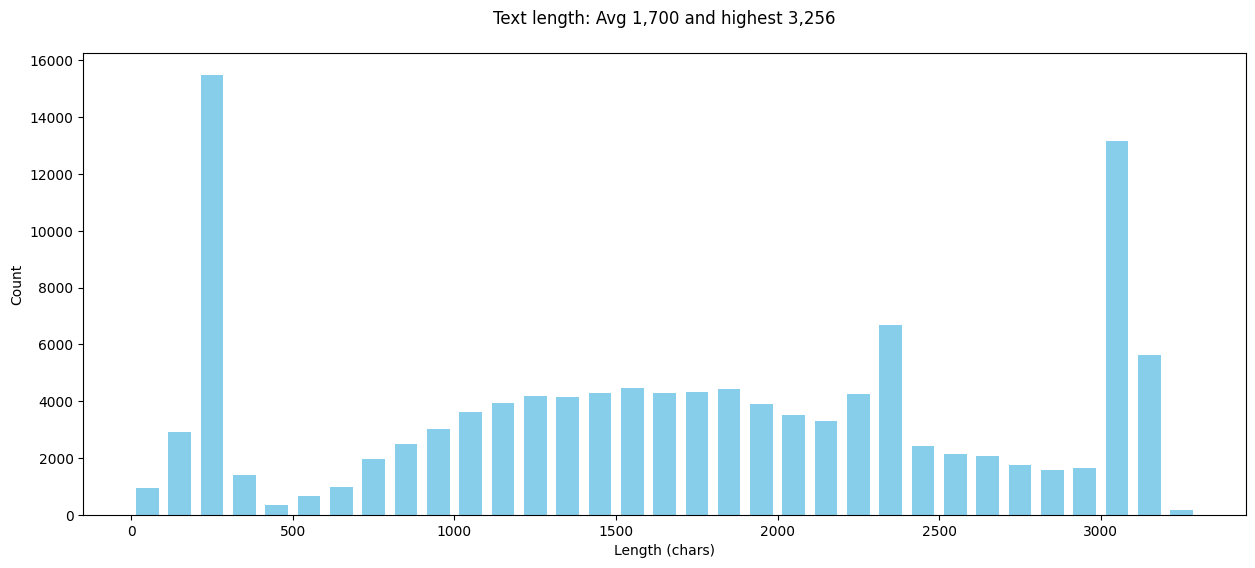

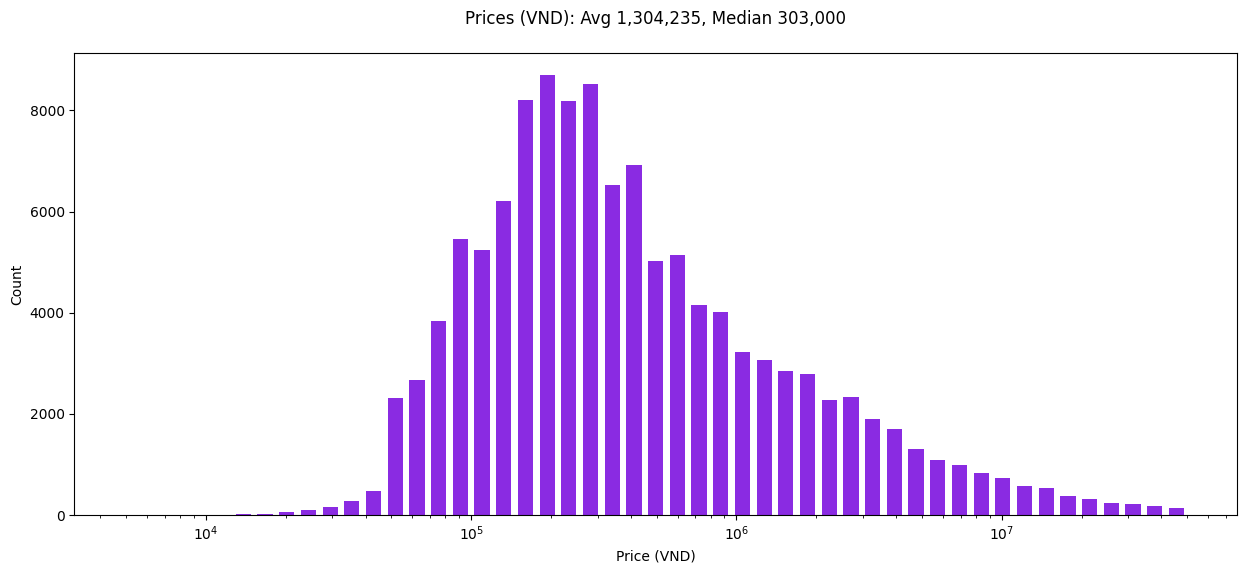

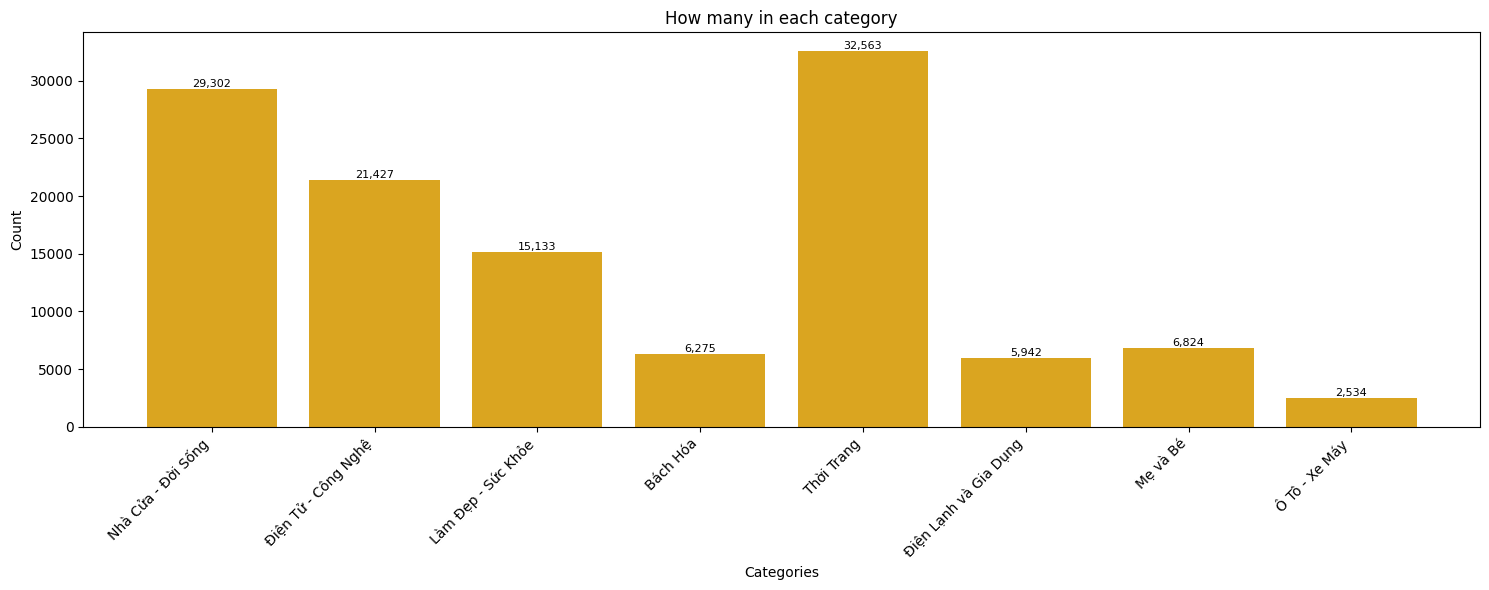

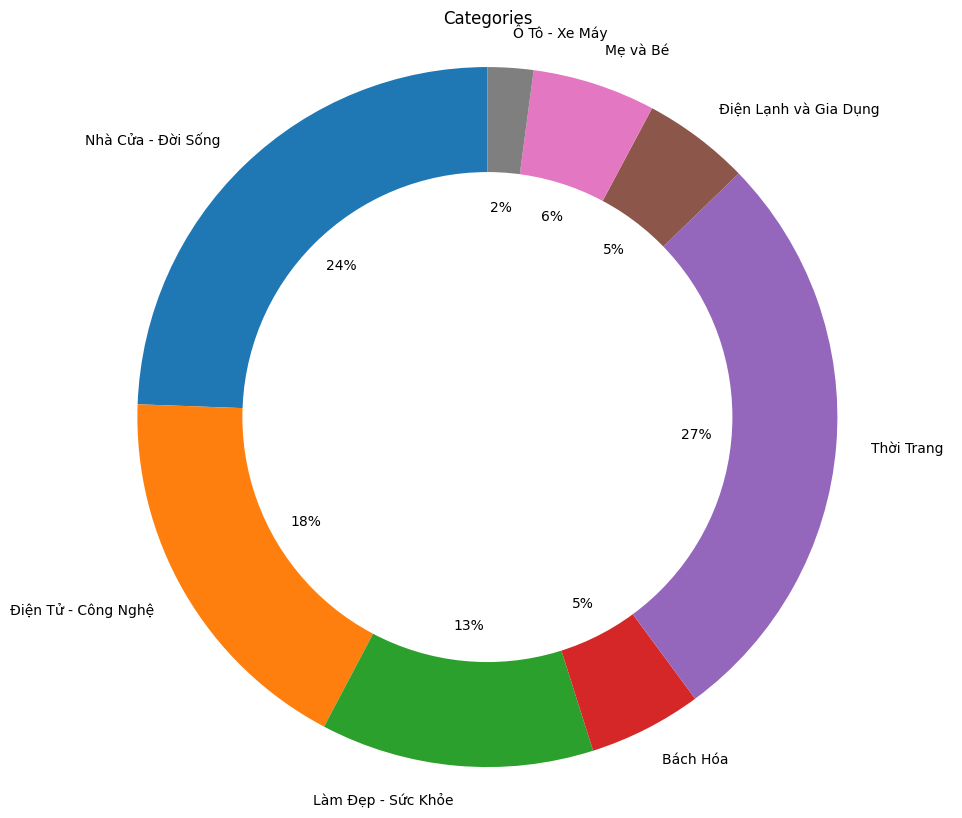

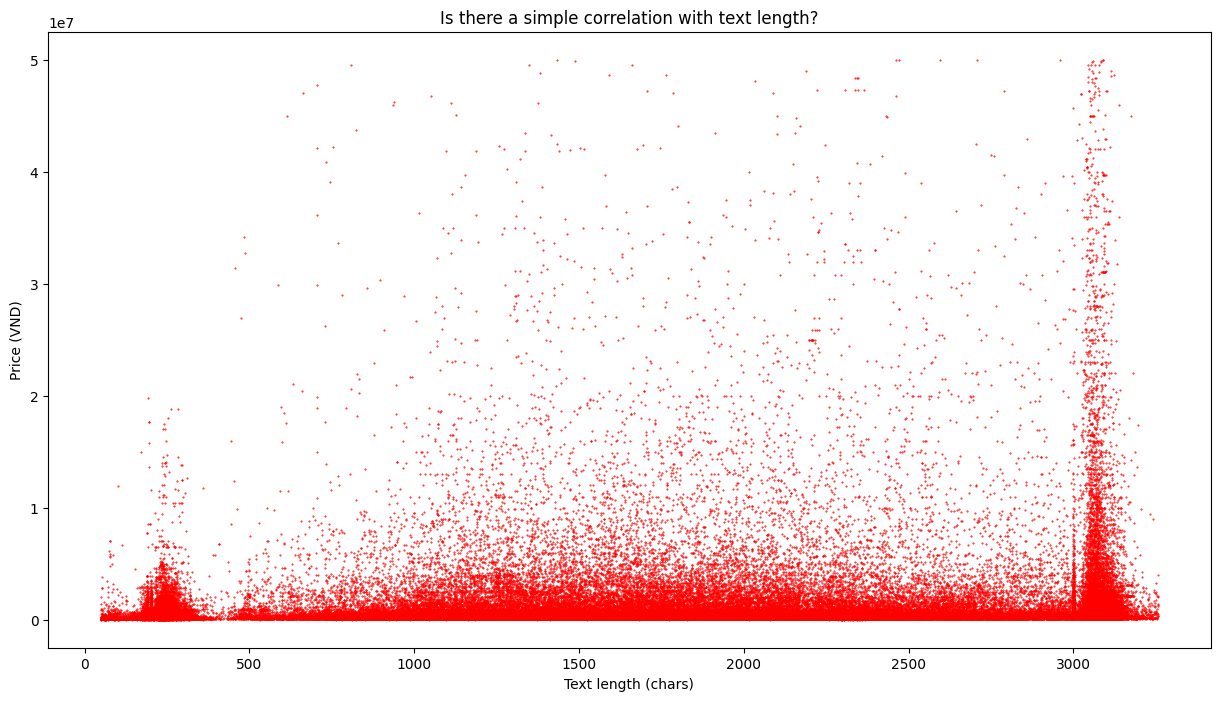

In [30]:
plot_eda(sample, prefix="03_after_sampling_")

In [31]:
# Compare before/after sampling
before_cats = Counter([it.category for it in items])
after_cats = Counter([it.category for it in sample])

print(f"{'Category':<30} {'Before dedup':>15} {'After sampling':>15} {'Change':>10}")
print("-" * 75)
for cat in sorted(before_cats.keys(), key=lambda c: before_cats[c], reverse=True):
    b = before_cats[cat]
    a = after_cats.get(cat, 0)
    pct_b = b / len(items) * 100
    pct_a = a / len(sample) * 100
    print(f"{cat:<30} {b:>10,} ({pct_b:4.1f}%) {a:>10,} ({pct_a:4.1f}%) {pct_a - pct_b:>+7.1f}%")

Category                          Before dedup  After sampling     Change
---------------------------------------------------------------------------
Thời Trang                         51,465 (35.0%)     32,563 (27.1%)    -7.9%
Nhà Cửa - Đời Sống                 31,987 (21.8%)     29,302 (24.4%)    +2.6%
Điện Tử - Công Nghệ                22,734 (15.5%)     21,427 (17.9%)    +2.4%
Làm Đẹp - Sức Khỏe                 16,730 (11.4%)     15,133 (12.6%)    +1.2%
Bách Hóa                            8,073 ( 5.5%)      6,275 ( 5.2%)    -0.3%
Mẹ và Bé                            7,247 ( 4.9%)      6,824 ( 5.7%)    +0.8%
Điện Lạnh và Gia Dụng               6,005 ( 4.1%)      5,942 ( 5.0%)    +0.9%
Ô Tô - Xe Máy                       2,609 ( 1.8%)      2,534 ( 2.1%)    +0.3%


## Step 8: Split dataset

Split into train / validation / test.

In [32]:
test = sample[:TEST_SIZE]
val = sample[TEST_SIZE:TEST_SIZE + VAL_SIZE]
train = sample[TEST_SIZE + VAL_SIZE:]

print(f"Train: {len(train):,}")
print(f"Val:   {len(val):,}")
print(f"Test:  {len(test):,}")
print(f"Total: {len(train) + len(val) + len(test):,}")

Train: 110,000
Val:   5,000
Test:  5,000
Total: 120,000


In [33]:
# Sanity check: no data leakage between splits
train_titles = set(it.title for it in train)
val_titles = set(it.title for it in val)
test_titles = set(it.title for it in test)

leak_tv = train_titles & val_titles
leak_tt = train_titles & test_titles
leak_vt = val_titles & test_titles

print(f"Train-Val overlap: {len(leak_tv)} titles")
print(f"Train-Test overlap: {len(leak_tt)} titles")
print(f"Val-Test overlap: {len(leak_vt)} titles")

if len(leak_tv) + len(leak_tt) + len(leak_vt) == 0:
    print("No data leakage detected.")
else:
    print("WARNING: Data leakage detected!")

Train-Val overlap: 0 titles
Train-Test overlap: 0 titles
Val-Test overlap: 0 titles
No data leakage detected.


## Step 9: Push to HuggingFace Hub

Push the final dataset as `SeanSunny/items_raw_tv_v4`.

In [34]:
from huggingface_hub import login
from dotenv import load_dotenv
import os

load_dotenv(override=True)
hf_token = os.environ.get("HF_TOKEN")

if hf_token:
    login(hf_token, add_to_git_credential=True)
    print("Logged in to HuggingFace.")
else:
    print("HF_TOKEN not found in .env. Set it to push.")

Token has not been saved to git credential helper.
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Cannot authenticate through git-credential as no helper is defined on your machine.
You might have to re-authenticate when pushing to the Hugging Face Hub.
Run the following command in your terminal in case you want to set the 'store' credential helper as default.

git config --global credential.helper store

Read https://git-scm.com/book/en/v2/Git-Tools-Credential-Storage for more details.
Logged in to HuggingFace.


In [35]:
# Push to Hub
print(f"Pushing to {HF_DATASET_NAME}...")
Item.push_to_hub(HF_DATASET_NAME, train, val, test)
print(f"Done! Dataset: https://huggingface.co/datasets/{HF_DATASET_NAME}")

Pushing to SeanSunny/items_raw_tv_v4...


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/110 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

...

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/5 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Done! Dataset: https://huggingface.co/datasets/SeanSunny/items_raw_tv_v4


## Summary

| Step | Result |
|---|---|
| Raw JSONL files | 263 files, ~158K items |
| After parse + category map | ~157K items (8 categories) |
| After dedup | ~147K items |
| Weighted sampling | 120K items (price^2 + penalties) |
| Split | 110K train / 5K val / 5K test |
| HuggingFace | `SeanSunny/items_raw_tv_v4` |